### 10. 데이터프레임
### 10.1 데이터프레임의 정의
- 데이터프레임은 통계적 모형화에서 가장 표준적인 데이터 형태이다.
- 리스트의 일종으로, 각 성분이 길이가 모두 같은 벡터로 이루어진 리스트라 할 수 있다.
- 2차원 형식의 데이터 구조를 가진다는 측면에서는 행렬과 동일하나 데이터프레임은 각 열별(변수별)로만 데이터 형(수치형,인자형 등)이 같으면 된다는 점에서 구분된다.
- R에서 자체적으로 제공하는 데이터들은 대부분 데이터프레임의 속성을 가지고 있다.

In [7]:
year = 2011:2014
winner = c("SLN", "SFN", "BOS", "SFN")
loser = c("TEX", "DET", "SLN", "KCA")
wins = c(4, 4, 4, 4)
losses = c(3, 0, 3, 3)
WS = data.frame(year, winner, loser, wins, losses)

print(WS)
print(paste('mode:',mode(WS))) ; print(paste('class:',class(WS)))
print('==')
print(mode(WS[,1])) ; print(class(WS[,1]))
print(mode(WS[,1]*1.0)) ; print(class(WS[,1]*1.0))  # 1.0을 곱하면서 실수형으로 바뀜

  year winner loser wins losses
1 2011    SLN   TEX    4      3
2 2012    SFN   DET    4      0
3 2013    BOS   SLN    4      3
4 2014    SFN   KCA    4      3
[1] "mode: list"
[1] "class: data.frame"
[1] "=="
[1] "numeric"
[1] "integer"
[1] "numeric"
[1] "numeric"


In [8]:
colnames(WS); print(rownames(WS))

[1] "year"   "winner" "loser"  "wins"   "losses"

[1] "1" "2" "3" "4"


In [ ]:
str(WS)

'data.frame':	4 obs. of  5 variables:
 $ year  : int  2011 2012 2013 2014
 $ winner: chr  "SLN" "SFN" "BOS" "SFN"
 $ loser : chr  "TEX" "DET" "SLN" "KCA"
 $ wins  : num  4 4 4 4
 $ losses: num  3 0 3 3


### 8.2 데이터프레임의 인덱싱


- 리스트와 같이 인덱스 값이나 이름을 통해 접근할 수 있다.
- 이차원의 자료구조를 가지므로 행렬의 인덱싱 방법을 차용할 수도
있다.

In [9]:
#print(names(WS))
#print(WS[[2]]) ; print(WS$loser) ;
print(WS[1,]) ; print(WS[,1])
#print(WS["3",])

  year winner loser wins losses
1 2011    SLN   TEX    4      3
[1] 2011 2012 2013 2014


- 예: 행과 열에 대해 부분 데이터 프레임을 추출하는 것이 가능하다 (필터링)

In [10]:
print(WS[WS$year==2012,]) ; print(WS[c(2,4),])

  year winner loser wins losses
2 2012    SFN   DET    4      0
  year winner loser wins losses
2 2012    SFN   DET    4      0
4 2014    SFN   KCA    4      3


In [11]:
print(WS[c(2,4),])

  year winner loser wins losses
2 2012    SFN   DET    4      0
4 2014    SFN   KCA    4      3


In [12]:
print(WS[winner=="SFN",])

  year winner loser wins losses
2 2012    SFN   DET    4      0
4 2014    SFN   KCA    4      3


### 8.3 데이터프레임에 함수 적용하기
- 데이터 프레임의 특정 열은 벡터이다.

In [13]:
str(faithful)

'data.frame':	272 obs. of  2 variables:
 $ eruptions: num  3.6 1.8 3.33 2.28 4.53 ...
 $ waiting  : num  79 54 74 62 85 55 88 85 51 85 ...


In [14]:
print(median(faithful[,2])) ; print(median(faithful$waiting))

[1] 76
[1] 76


In [17]:
print(sapply(faithful, median)) # 열단위 중앙값
print(apply(faithful, 2, mean)) # 열단위 평균
print(colMeans(faithful))       # 열단위 평균

eruptions   waiting 
        4        76 
eruptions   waiting 
 3.487783 70.897059 
eruptions   waiting 
 3.487783 70.897059 


In [21]:
vv = faithful[,1]
print(head(sort(vv)))
print(head(vv[order(vv)]))
faithful[order(vv),] -> kk
print(head(kk))

[1] 1.600 1.667 1.700 1.733 1.750 1.750
[1] 1.600 1.667 1.700 1.733 1.750 1.750
    eruptions waiting
19      1.600      52
58      1.667      64
115     1.700      59
55      1.733      54
14      1.750      47
17      1.750      62


In [23]:
print(head(as.data.frame(lapply(faithful,sort))))
print(tail(as.data.frame(lapply(faithful,sort))))

  eruptions waiting
1     1.600      43
2     1.667      45
3     1.700      45
4     1.733      45
5     1.750      46
6     1.750      46
    eruptions waiting
267     4.933      91
268     4.933      92
269     5.000      93
270     5.033      93
271     5.067      94
272     5.100      96


### 8.4 데이터프레임의 결합
- 두 데이터 프레임을 결합할 수 있다.
- 결합의 기준이 되는 key 변수를 보통 지정함.

In [25]:
d1 = data.frame(kids=c("Jack","Jill","Jillian","John"), states=c("CA","MA","MA","HI"))
d2 = data.frame(ages=c(10,7,12),kids=c("Jill","Lillian","Jack"))
d = merge(d1,d2) ; d <- merge(d1,d2,by="kids")
print(d)

  kids states ages
1 Jack     CA   12
2 Jill     MA   10


- full outer join: 기준변수를 기준으로 합집합으로 묶음
- left outer join: 기준변수를 기준으로 왼쪽 데이터 프레임의 모든 샘플을 남겨두고 묶음
- right outer join: 기준변수를 기준으로 오른쪽 데이터 프레임의 모든 샘플을 남겨두고 묶음

In [26]:
df = merge(d1,d2,all=T)
print(df)

ddl = merge(d1,d2,all.x=T)
print(ddl)
dd2 = merge(d1,d2,all.y=T)
print(dd2)

     kids states ages
1    Jack     CA   12
2    Jill     MA   10
3 Jillian     MA   NA
4    John     HI   NA
5 Lillian   <NA>    7
     kids states ages
1    Jack     CA   12
2    Jill     MA   10
3 Jillian     MA   NA
4    John     HI   NA
     kids states ages
1    Jack     CA   12
2    Jill     MA   10
3 Lillian   <NA>    7


### 11. 데이터 시각화
### 11.1 데이터시각화란?
- 데이터나 정보를 그래프, 차트 혹은 또다른 시각적 형식을 통해 표현하는 것
- 데이터를 이미지와 연결시키는 일련의 방식
- 텍스트나 숫자보다 시각적인 이미지가 보다 직관적인 인지를 가능케 하고 강렬한 인상을 남김
- 다양한 시각화를 통해 데이터나 자료에 대한 다층적인 이해 가능
- 빅데이터 시대에 대용량의 데이터에 대한 효과적인 요약 가능

### 11.2 R Base graphics
- R에 기본적으로 내장되어 있는 시각화도구
- 다양한 종류의 그래프 생성이 가능하며 매개변수(graphical parameter)의 조정을 통해 세부적인 그래프의 모양 및 내용을 조정할 수 있음

### 11.3 ggplot2 패키지
- 시각화를 위해 개발된 package로 Wilkilson에 의해 개발된 그래픽 문법(grammar of graphics)에 기초하고 있으며 현재는 R을 통한 데이터시각화의 표준이 되어가고 있음
- 독립적인 시각적 구성요소들을 정의하고 이를 다양한 방식으로 구성하는(쌓아올리는) 방식으로 그래프를 생성함
- 원시데이터를 나타내는 층(layer)를 먼저 정의하고 여기에 각종 주석이나 통계객체 등을 더해 나갈 수 있음
- 시각화 과정을 표준화함으로써 그래픽 문법에 어느 정도 익숙해지면 다양한 그래프를 자유자재로 그릴 수 있음

본 강의에서는 ggplot2의 활용을 중심으로 시각화를 통한 데이터의 요약을 학습할 것임

### 11.4 ggplot2 패키지에 사용되는 문법의 구성 요소 및 용어
- data
    - 시각화에 사용될 데이터를 정의
    - data.frame 형식
    - ggplot()에 정의
- aesthetics
    - 데이터의 시각적 표현양식 정의 (mapping)
    - x축, y축의 정의
    - color, size, shape 등을 정의
    - aes()에 정의
- geometry
    - 표현할 그림의 기하 객체
    - 점, 선, 바 등등
    - geom_point(), geom_line(), geom_bar() 등등에 정의
- stats
    - 통계변환 혹은 데이터 요약
    - 모든 기하 객체에는 그에 대응되는 통계변환이 존재
- facets
    - 격자형 그림 배치를 위한 그룹화
    - facet_grid()에 정의
- scale
    - 데이터와 aesthetics(color, size, shape) 사이의 mapping을 조정
    - 보통 색깔을 조정하기 위해 사용됨
- coordinates
    - 좌표 정의

#### 막대그래프 (범주형 자료)
- 보통 가로축에 범주, 세로축에 수치를 표시함. 이 때 수치에는 자료값, 도수, 상대도수 등이 포함됨
- geom_bar() 이용

In [27]:
library(ggplot2)
str(diamonds)

tibble [53,940 × 10] (S3: tbl_df/tbl/data.frame)
 $ carat  : num [1:53940] 0.23 0.21 0.23 0.29 0.31 0.24 0.24 0.26 0.22 0.23 ...
 $ cut    : Ord.factor w/ 5 levels "Fair"<"Good"<..: 5 4 2 4 2 3 3 3 1 3 ...
 $ color  : Ord.factor w/ 7 levels "D"<"E"<"F"<"G"<..: 2 2 2 6 7 7 6 5 2 5 ...
 $ clarity: Ord.factor w/ 8 levels "I1"<"SI2"<"SI1"<..: 2 3 5 4 2 6 7 3 4 5 ...
 $ depth  : num [1:53940] 61.5 59.8 56.9 62.4 63.3 62.8 62.3 61.9 65.1 59.4 ...
 $ table  : num [1:53940] 55 61 65 58 58 57 57 55 61 61 ...
 $ price  : int [1:53940] 326 326 327 334 335 336 336 337 337 338 ...
 $ x      : num [1:53940] 3.95 3.89 4.05 4.2 4.34 3.94 3.95 4.07 3.87 4 ...
 $ y      : num [1:53940] 3.98 3.84 4.07 4.23 4.35 3.96 3.98 4.11 3.78 4.05 ...
 $ z      : num [1:53940] 2.43 2.31 2.31 2.63 2.75 2.48 2.47 2.53 2.49 2.39 ...


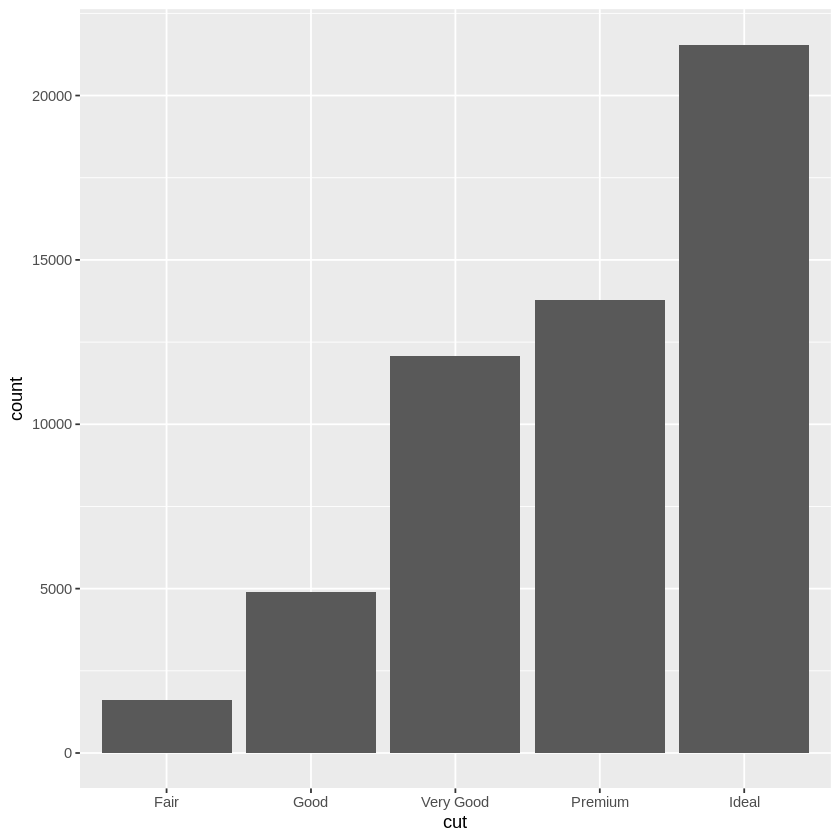

In [31]:
ggplot(diamonds, aes(cut)) +  geom_bar()
#ggplot(diamonds, aes(cut, fill = clarity)) +  geom_bar()  # cutting의 질에 대한 막대그래프, clarity 함께 표기
#ggplot(diamonds, aes(cut, fill = clarity)) +  geom_bar(position="dodge")  # cutting의 질에 대한 막대그래프, clarity 함께 표기
#ggplot(diamonds, aes(cut, fill = clarity)) +  geom_bar(position="fill")  # 상대도수 표기

#### 원형그래프  (범주형 자료)
- 파이 모양의 원에 각 범주가 차지하는 비율을 부채꼴의 중심각 혹은 면적에 비례하도록 표현
- coord_polar() 이용

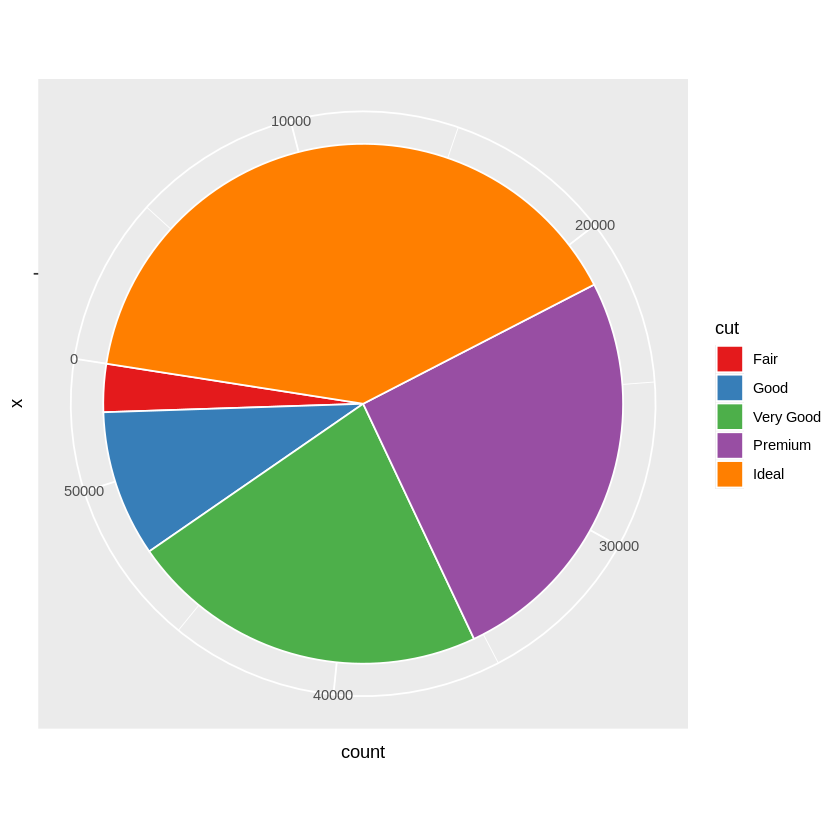

In [32]:
ggplot(diamonds, aes(x="", fill = cut)) +
    geom_bar(width=2, color="white") +
    coord_polar("y", start=30) +
    scale_fill_brewer(palette="Set1")


      Fair       Good  Very Good    Premium      Ideal 
0.02984798 0.09095291 0.22398962 0.25567297 0.39953652 
       Var1       Freq
1      Fair 0.02984798
2      Good 0.09095291
3 Very Good 0.22398962
4   Premium 0.25567297
5     Ideal 0.39953652


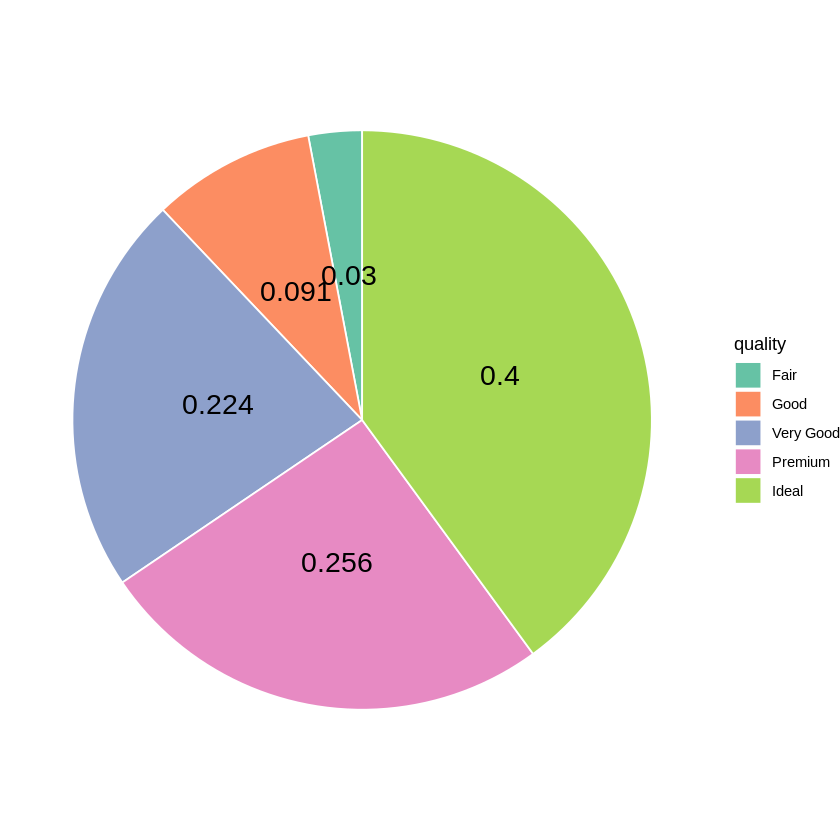

In [35]:
x = table(diamonds$cut)/length(diamonds$cut)  # 상대도수 계산
print(x)
x1 = as.data.frame(x)                         # 데이터프레임으로 저장
print(x1)

names(x1) = c("quality","proportion")         # 변수이름 재지정
ggplot(x1, aes(x="", y=proportion, fill=quality)) +
  geom_bar(stat="identity", width=1, color="white") +
  coord_polar("y", start=0) +
  theme_void() +
  geom_text(aes(label = round(proportion,3)), color = "black", size=6, position = position_stack(vjust = 0.5)) +
  scale_fill_brewer(palette="Set2")

**##과제 G1##**

mpg 데이터(ggplot2에 내장)는 1999년과 2008년에 생산된 자동차들의 연비에 대한 정보를 담고 있고. 234개의 관측치와 11개의 변수가 존재한다. 제조업체(manufacturer)에 대한 막대그래프 및 원형그래프를 그려 보아라. 막대그래프에 각 실린더 개수별(cyl) 차 유형(class)이 어떻게 구성되어 있는지를 살펴볼 수 있도록 표시하되 도수, 상대비율이 표시된 그래프를 각각 그려라.

tibble [234 × 11] (S3: tbl_df/tbl/data.frame)
 $ manufacturer: chr [1:234] "audi" "audi" "audi" "audi" ...
 $ model       : chr [1:234] "a4" "a4" "a4" "a4" ...
 $ displ       : num [1:234] 1.8 1.8 2 2 2.8 2.8 3.1 1.8 1.8 2 ...
 $ year        : int [1:234] 1999 1999 2008 2008 1999 1999 2008 1999 1999 2008 ...
 $ cyl         : int [1:234] 4 4 4 4 6 6 6 4 4 4 ...
 $ trans       : chr [1:234] "auto(l5)" "manual(m5)" "manual(m6)" "auto(av)" ...
 $ drv         : chr [1:234] "f" "f" "f" "f" ...
 $ cty         : int [1:234] 18 21 20 21 16 18 18 18 16 20 ...
 $ hwy         : int [1:234] 29 29 31 30 26 26 27 26 25 28 ...
 $ fl          : chr [1:234] "p" "p" "p" "p" ...
 $ class       : chr [1:234] "compact" "compact" "compact" "compact" ...



 4  5  6  8 
81  4 79 70 

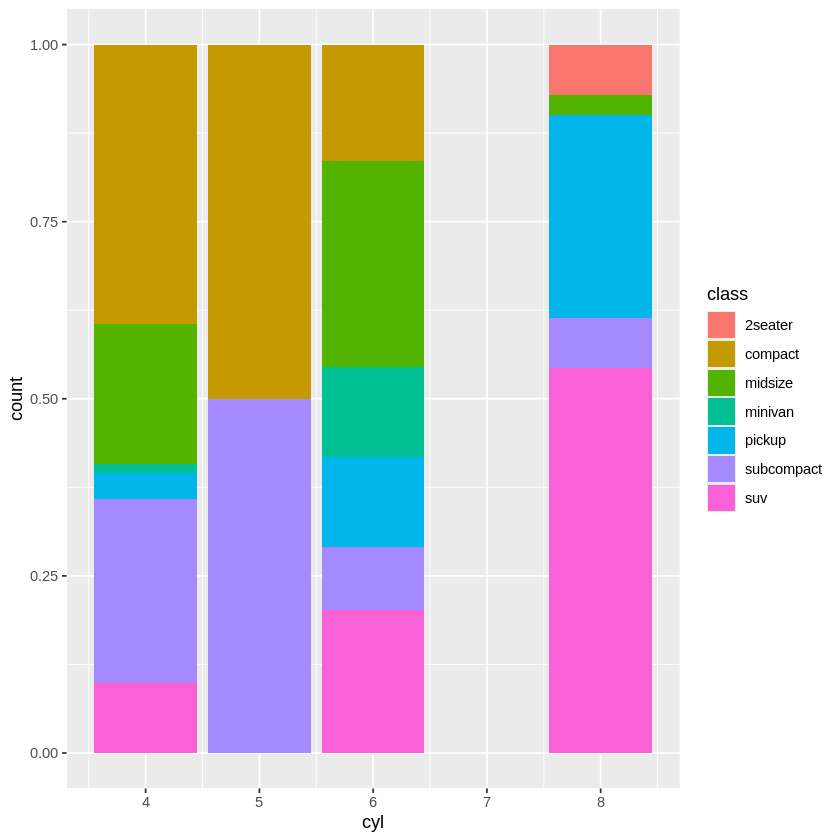

In [36]:
str(mpg)
ggplot(mpg, aes(cyl, fill = class)) +  geom_bar(position="fill")
table(mpg$cyl)

#### 히스토그램 (수치형자료)
- 데이터를 구간을 정하여 계급화하고 각 계급에 대한 도수(빈도)를 세어 그래프로 나타낸 것
- 연속형 변수의 분포를 나타내기 위한 그래프
- geom_histogram() 이용

In [17]:
install.packages("ggplot2")
install.packages("Matrix")

library(ggplot2)


Warning message:
“dependency ‘Matrix’ is not available”
also installing the dependency ‘mgcv’


Warning message in install.packages("ggplot2"):
“installation of package ‘mgcv’ had non-zero exit status”
Warning message in install.packages("ggplot2"):
“installation of package ‘ggplot2’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



ERROR: Error in library(ggplot2): there is no package called ‘ggplot2’


In [15]:
library(MASS)
library(ggplot2)

str(birthwt)
ggplot(birthwt, aes(x=bwt)) +
     geom_histogram(fill="white", colour="black") #회색배경은 ggplot의 기본배경이다.

ERROR: Error in library(ggplot2): there is no package called ‘ggplot2’


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


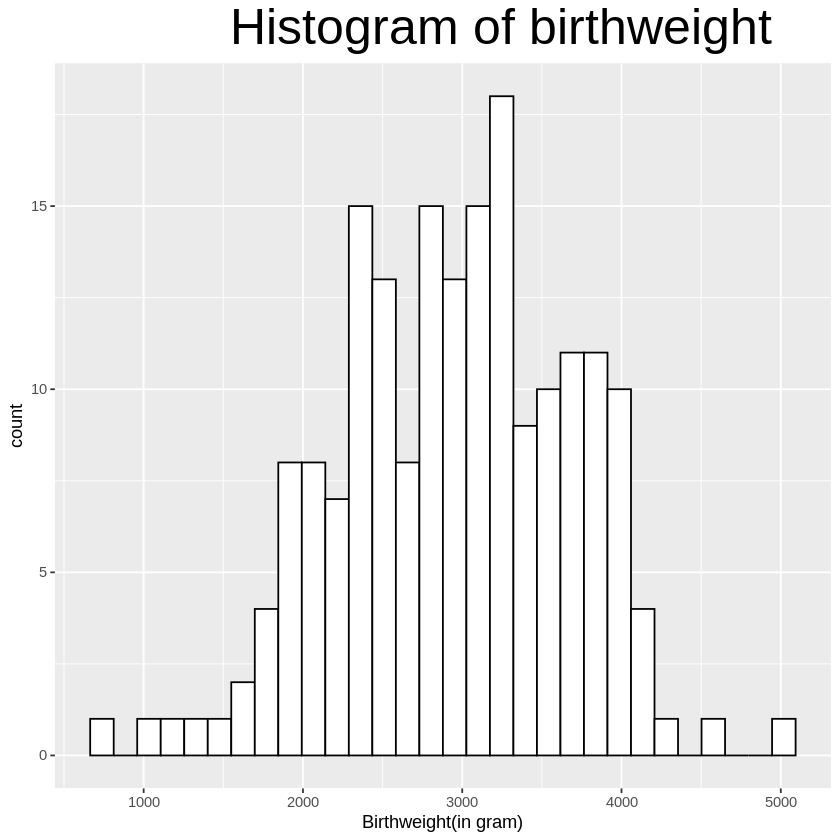

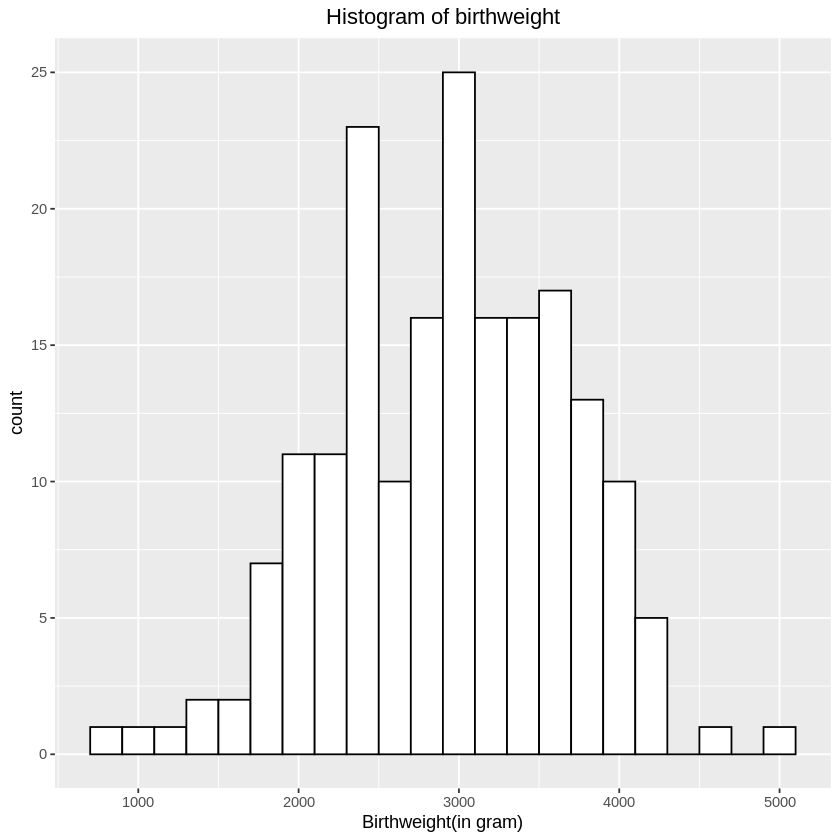

In [9]:
library(MASS)
# 189명의 신생아의 체중과 저체중여부(2.5kg 미만), 산모의 여러 특성이 포함되어 있는 데이터
ggplot(birthwt, aes(x=bwt)) +
     geom_histogram(fill="white", colour="black") +
     labs(title="Histogram of birthweight", x ="Birthweight(in gram)") +  # 제목 및 축 이름 지정
     theme(plot.title = element_text(hjust = 0.75, size=30))              # 제목 중앙 정렬
ggplot(birthwt, aes(x=bwt)) +
     geom_histogram(binwidth=200,fill="white", colour="black") +
     labs(title="Histogram of birthweight", x ="Birthweight(in gram)") +  # 제목 및 축 이름 지정
     theme(plot.title = element_text(hjust = 0.5))                        # 제목 중앙정렬

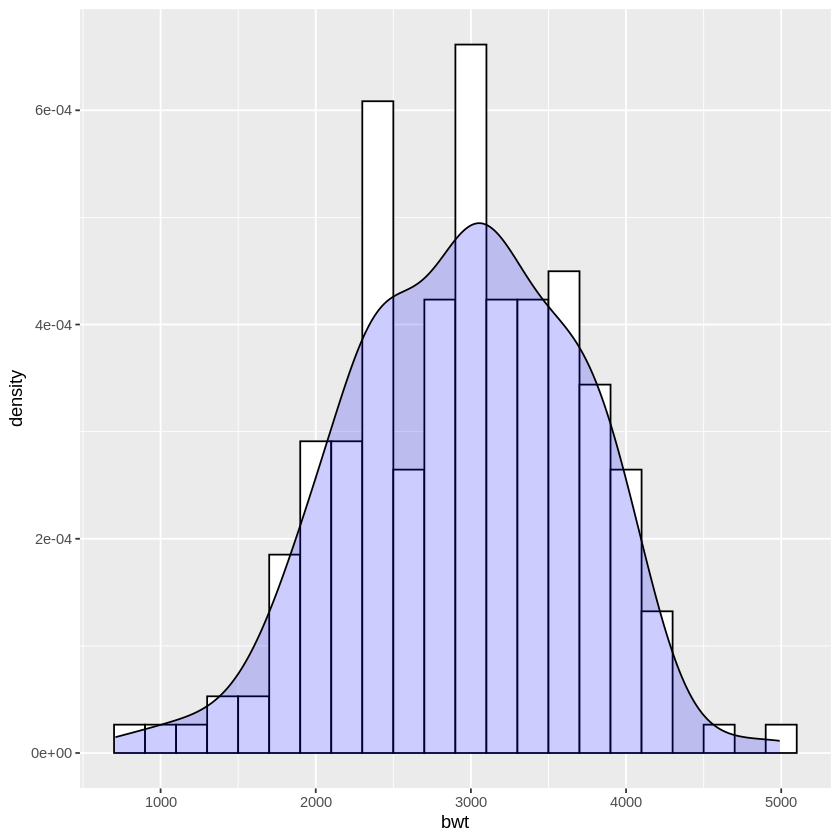

In [42]:
ggplot(birthwt, aes(x=bwt)) +
    geom_histogram(aes(y=..density..),binwidth=200, fill="white", colour="black") +
    geom_density(fill="blue",alpha=0.2)  #alpha: 투명도

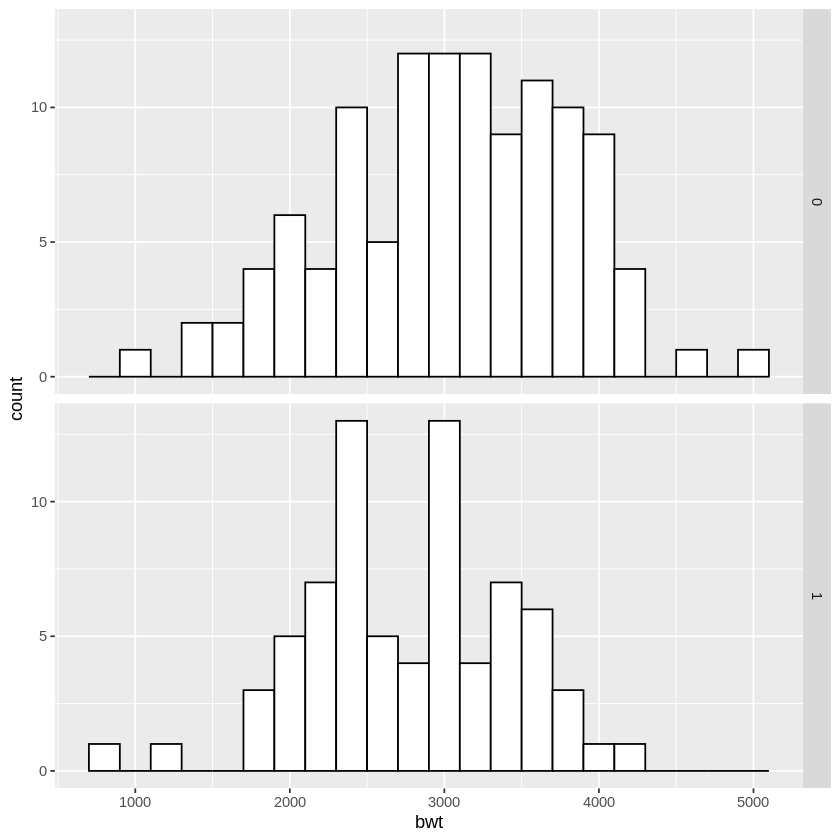

In [43]:
ggplot(birthwt, aes(x=bwt)) +
    geom_histogram(binwidth=200,fill="white", colour="black") +
    facet_grid(smoke ~ .)   # smoke 의 범주별로 그래프를 그림

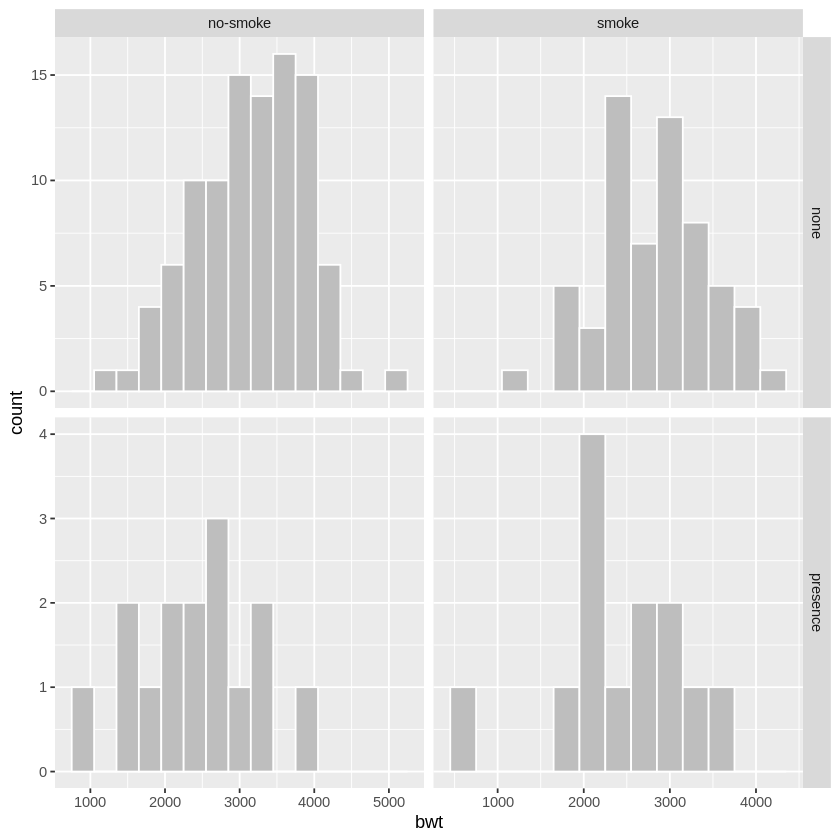

In [44]:
birthwt$smoke1 = factor(birthwt$smoke, levels=c(0,1), labels=c("no-smoke","smoke"))
birthwt$ui1 = factor(birthwt$ui, levels=c(0,1), labels=c("none","presence"))
ggplot(birthwt, aes(x=bwt)) +
    geom_histogram(binwidth=300,fill="gray", colour="white") +
    facet_grid(ui1~smoke1, scale="free")

#### 상자그림 (수치형 자료)
- five number summary(최소값, 1사분위수, 중앙값, 3사분위수, 최대값)에 근거하여 분포를 시각화
- 연속형 변수의 분포를 나타내기 위한 것이며 이상점의 존재 여부도 함께 표시
- 상자의 아래 위 경계가 각각 1,3사분위수이며 가운데 굵은 선이 중앙값임
- geom_boxplot() 이용

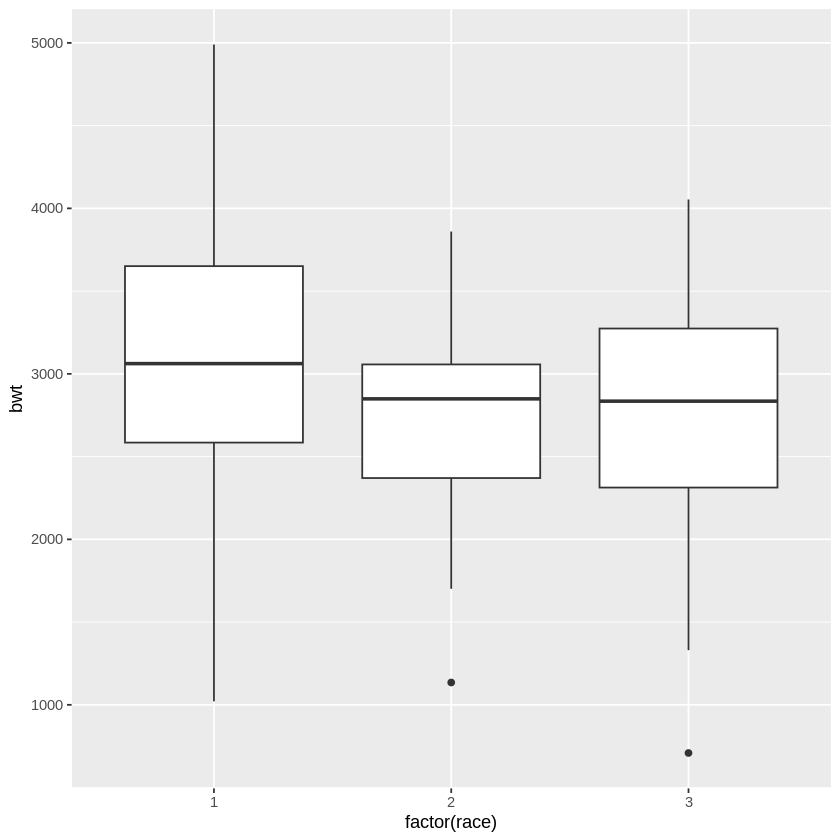

In [45]:
ggplot(birthwt, aes(x=factor(race),y=bwt)) +
    geom_boxplot()

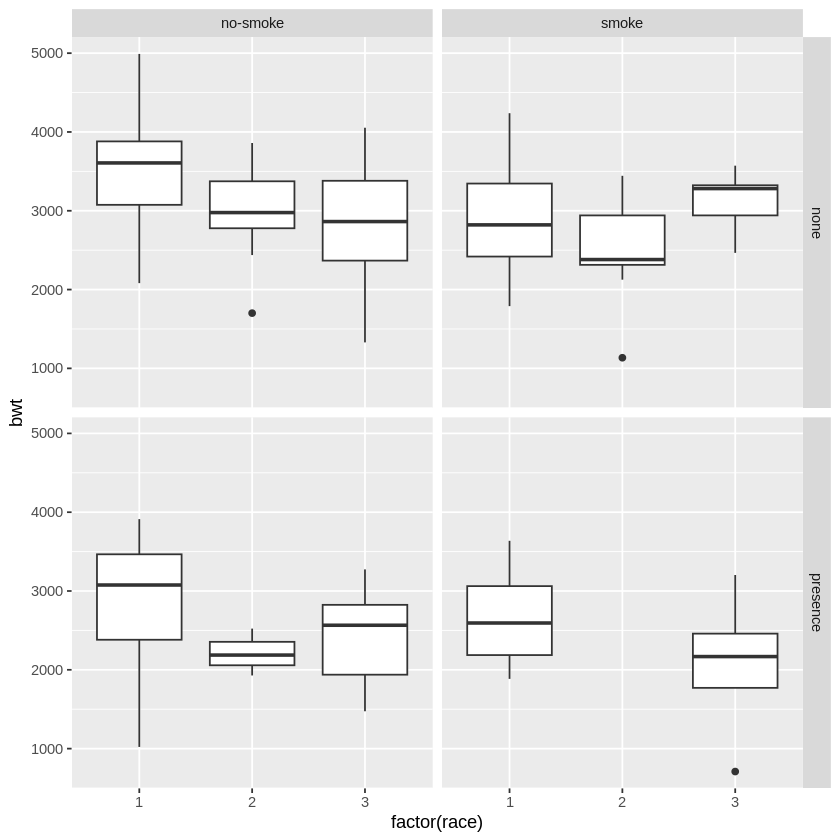

In [46]:
ggplot(birthwt, aes(x=factor(race),y=bwt)) +
    geom_boxplot() +
    facet_grid(ui1~smoke1)

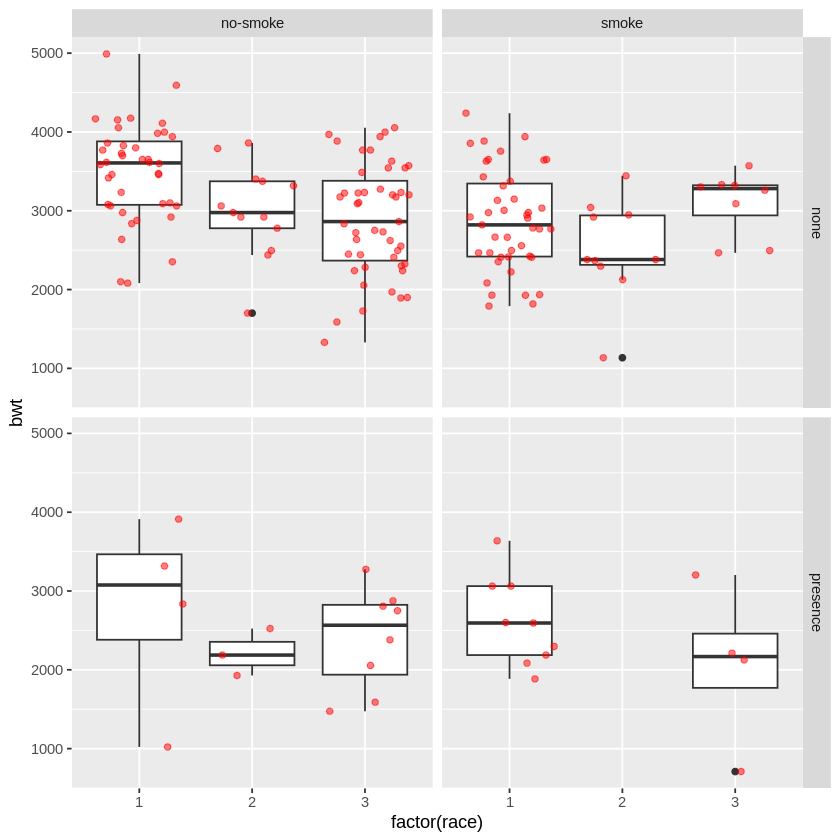

In [47]:
ggplot(birthwt, aes(x=factor(race),y=bwt)) +
    geom_boxplot() +
    facet_grid(ui1~smoke1) +
    geom_jitter(colour="red",alpha=0.5)  # 실제값을 흔들어서 찍어줌

##**과제 G2**##

 고속연비(hwy)의 분포를 보기 위한 히스토그램을 그리고 density 곡선을 겹쳐서 그려보아라. 분포의 형태가 어떠한지 살펴 보아라. 엔진구동방식(drv)과 실린더 개수(cyl)에 따란 각각 고속연비의 분포를 보기 위한 히스토그램을 그리고 서로 비교하여 보시오. 적절한 상자그림을 그려 보시오.

#### 산점도 (두 수치형 변수)
- 두 수치형 변수의 관측 순서쌍을 이차원 평면 상에 나타냄
- 한 변수의 변화에 따른 다른 변수의 변화 trend 등을 파악하기 좋음
- geom_point() 이용

[1] 53940

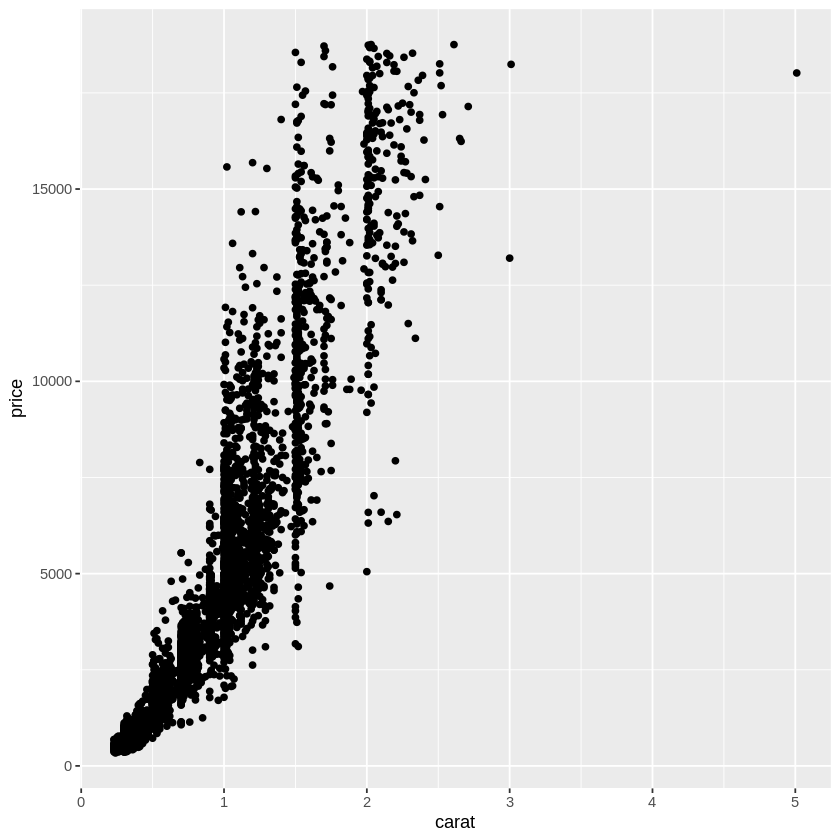

In [49]:
nrow(diamonds)
N = nrow(diamonds)    # 표본의 크기
set.seed(1)
diamonds1 = diamonds[sample(1:N,0.1*N),]                # 전체 중 10%의 표본만을 추출 (간단히 그림을 그리기 위함)
ggplot(diamonds1, aes(x=carat, y=price)) + geom_point() # 기본 산점도

- 점의 형태와 크기 그리고 색깔 지정 (shape, size, and color)

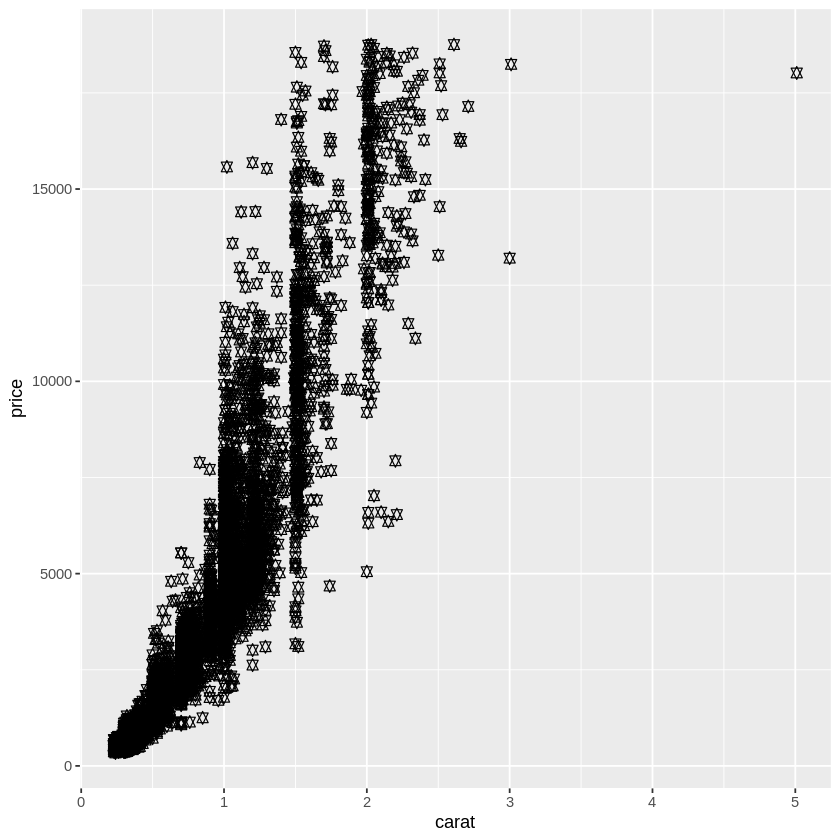

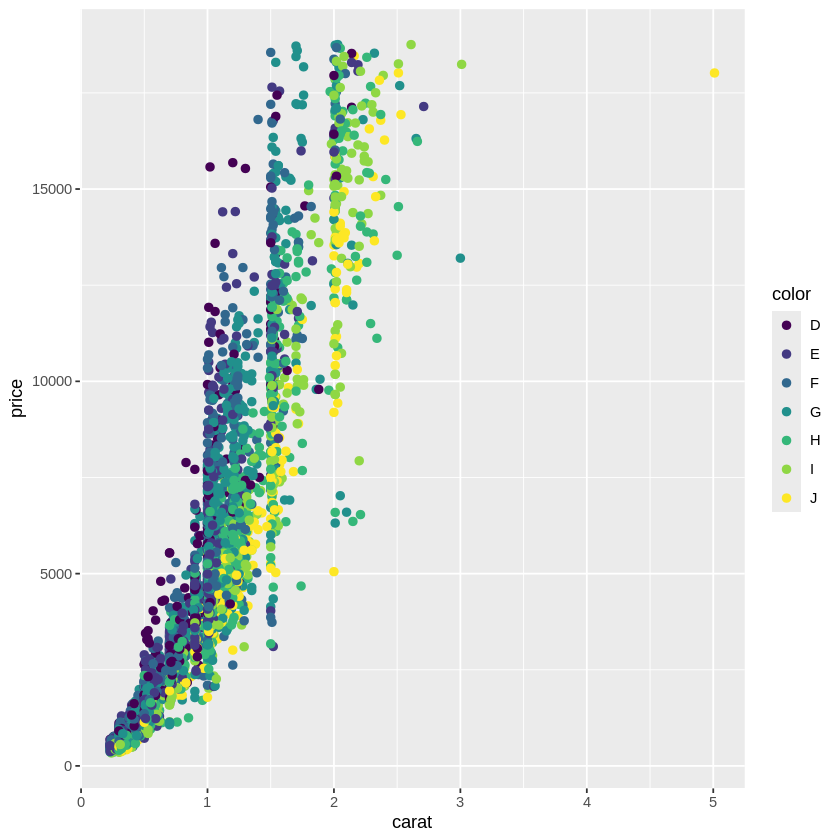

In [50]:
ggplot(diamonds1, aes(x=carat, y=price)) + geom_point(shape=11, size=2)
ggplot(diamonds1, aes(x=carat, y=price, colour = color)) + geom_point(size=2)

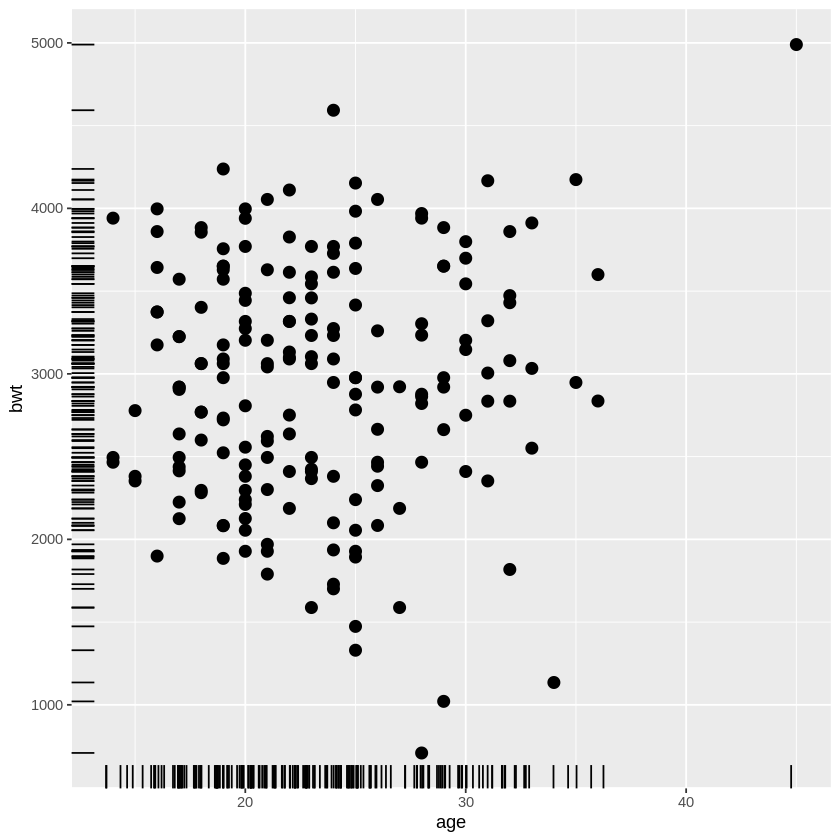

In [52]:
ggplot(birthwt, aes(x=age, y=bwt)) +
    geom_point(size=3) +
    geom_rug(position="jitter", size=.5)
  # 산모의 나이를 x축, 신생아의 체중을 y축으로 하는 산점도, 각 축 위에 주변분포를 함께 표현

   low age lwt race smoke ptl ht ui ftv  bwt   smoke1      ui1
85   0  19 182    2     0   0  0  1   0 2523 no-smoke presence
86   0  33 155    3     0   0  0  0   3 2551 no-smoke     none
87   0  20 105    1     1   0  0  0   1 2557    smoke     none
88   0  21 108    1     1   0  0  1   2 2594    smoke presence
89   0  18 107    1     1   0  0  1   0 2600    smoke presence
91   0  21 124    3     0   0  0  0   0 2622 no-smoke     none


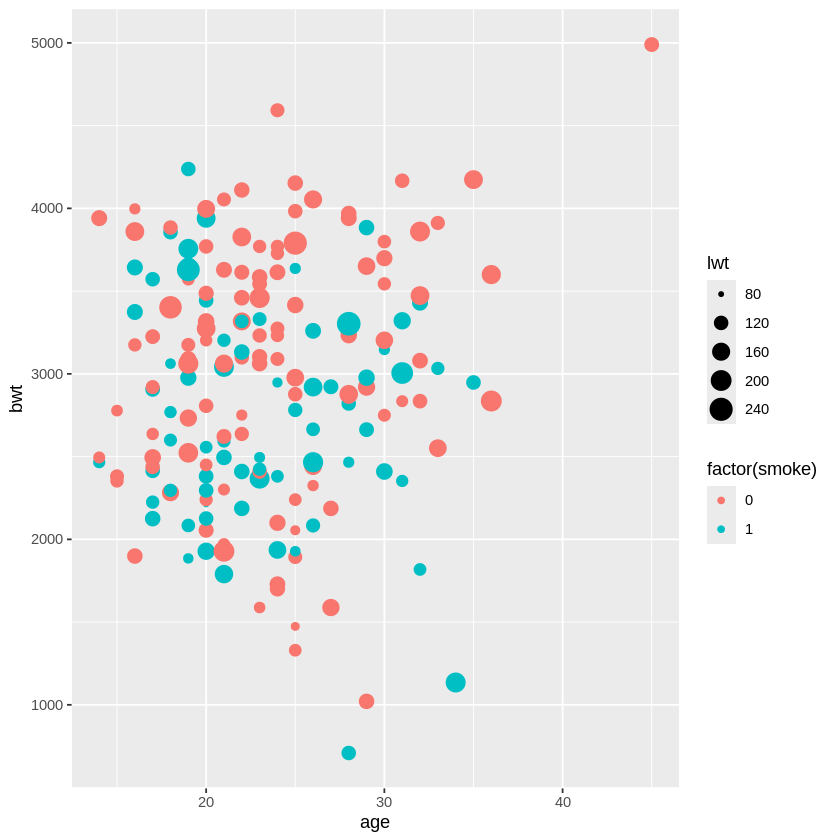

In [54]:
print(head(birthwt))
ggplot(birthwt, aes(x=age, y=bwt, size=lwt, colour = factor(smoke))) + geom_point()
# 두 가지 요소들로 크기와 색깔 구분

`geom_smooth()` using formula = 'y ~ x'


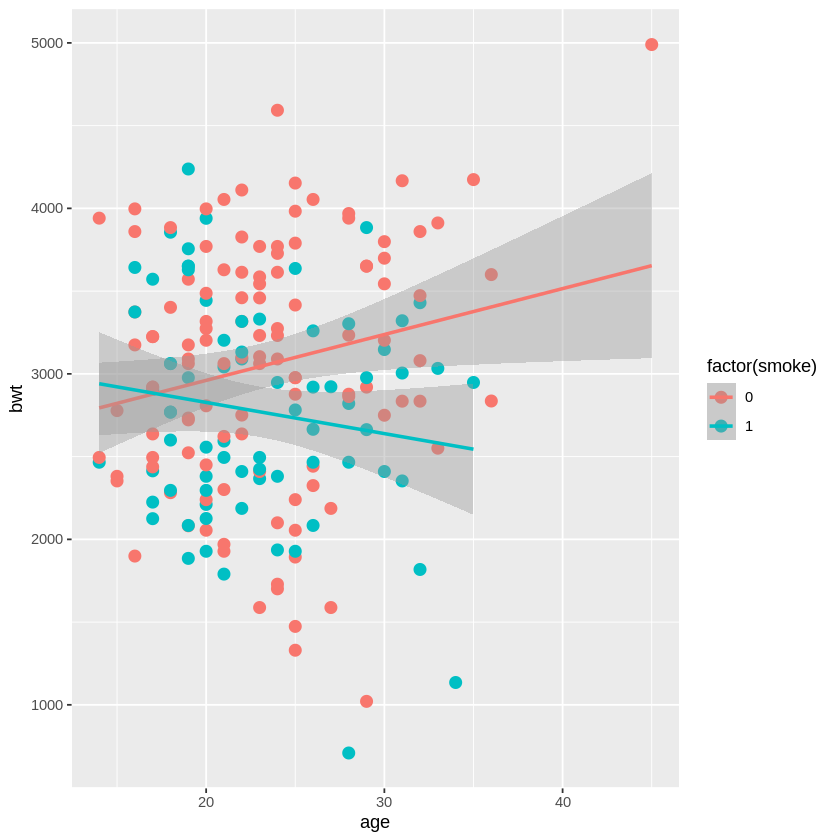

In [55]:
ggplot(birthwt, aes(x=age, y=bwt,colour = factor(smoke))) + geom_point(size=3) +
  geom_smooth(method=lm)
# stat_smooth(method=lm)로 선형추세선 표시. 일반적인 비선형추세선을 표시하고자 하는 경우 geom_smooth(method=loess)로 설정

#### 선그래프
- 한 변수의 변화에 따른 다른 변수(수치형)의 변화를 선으로 연결하여 나타내는 그래프
- x축에 표현되는 변수는 순서가 있는 범주형 변수도 가능하며, 연속형 변수더라도 몇 개의 이산적인 값을 취하는 경우를 보통 다룸.
- x축에는 시간변수가 종종 사용됨
- geom_line() 이용

In [57]:
install.packages("gapminder")
library(gapminder)
# 국가별 총생산, 기대수명 등에 대한 데이터
library(dplyr)
gap_LE <- gapminder %>%
    group_by(continent, year) %>%
    summarise(lifeExp=median(lifeExp))
# 연도에 따른 대륙별 평균수명의 중앙값 계산
print(head(gap_LE,20))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

`summarise()` has grouped output by 'continent'. You can override using the
`.groups` argument.


# A tibble: 20 × 3
# Groups:   continent [2]
   continent  year lifeExp
   <fct>     <int>   <dbl>
 1 Africa     1952    38.8
 2 Africa     1957    40.6
 3 Africa     1962    42.6
 4 Africa     1967    44.7
 5 Africa     1972    47.0
 6 Africa     1977    49.3
 7 Africa     1982    50.8
 8 Africa     1987    51.6
 9 Africa     1992    52.4
10 Africa     1997    52.8
11 Africa     2002    51.2
12 Africa     2007    52.9
13 Americas   1952    54.7
14 Americas   1957    56.1
15 Americas   1962    58.3
16 Americas   1967    60.5
17 Americas   1972    63.4
18 Americas   1977    66.4
19 Americas   1982    67.4
20 Americas   1987    69.5


`summarise()` has grouped output by 'continent'. You can override using the
`.groups` argument.


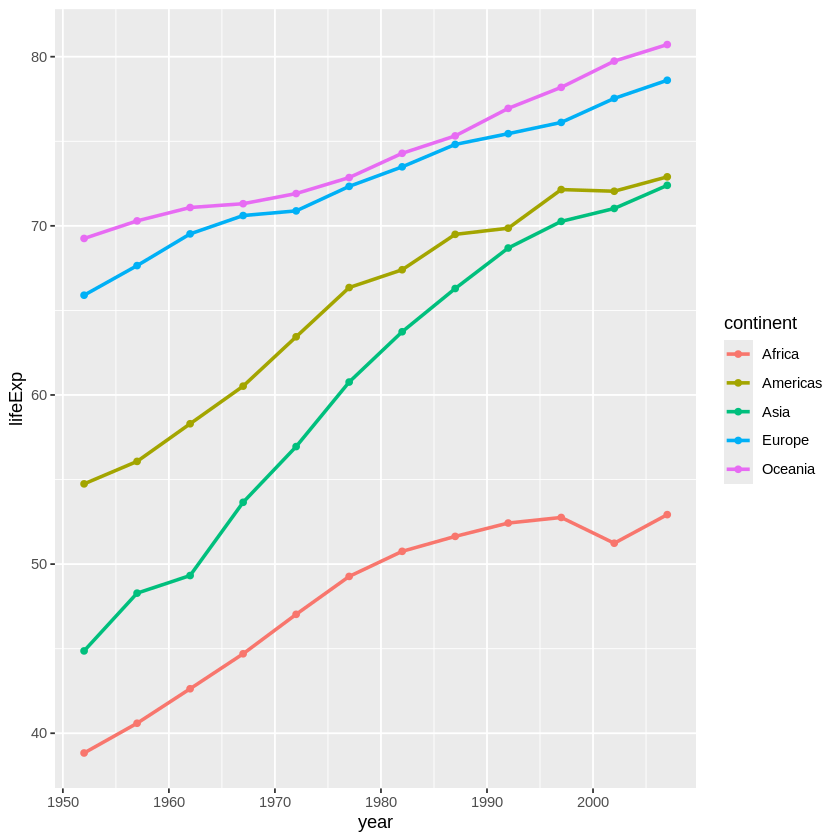

In [58]:
gapminder %>%
    group_by(continent, year) %>%
    summarise(lifeExp=median(lifeExp)) %>%
    ggplot(aes(x=year, y=lifeExp, color=continent)) +
     geom_line(size=1) +
     geom_point(size=1.5)

##**과제 G3**##
배기량(displ)에 따라 고속연비(hwy)가 어떻게 변화하는지 파악하기 위해 산점도를 그려라. 또한, 산점도 위에 실린더 개수(cyl)을 함께 표시하고 고속연비에 따라 점의 크기를 달리 하시오 (mpg 데이터 이용)